# Experiment 1 — Baseline CFM + Self-Attention on MNIST

**Purpose:** Establish the FID reference that all PhotonFlow experiments must match within 10%.
This is a *standard* electronic-hardware architecture — self-attention, LayerNorm, GELU.
It is **not** PhotonFlow. PhotonFlow replaces every component here with a photonic-native equivalent.

| Component | This Baseline | PhotonFlow (exp2+) |
|-----------|--------------|--------------------|
| Linear map | `nn.MultiheadAttention` | `MonarchLayer` (MZI mesh) |
| Normalization | `LayerNorm` | `DivisivePowerNorm` (microring feedback) |
| Activation | `GELU` | `SaturableAbsorber` tanh(αx)/α (graphene waveguide) |
| Noise | none | Shot noise + thermal crosstalk |

**Architecture:** Patch-based transformer (DiT-style)
- MNIST 28×28 → 49 non-overlapping 4×4 patches → Linear(16, 256)
- 4 × `BaselineCFMBlock`: adaLN-Zero + 4-head self-attention + GELU MLP
- Linear(256, 16) per patch → reshape to 784

**Training:** CFM loss (Lipman et al. 2023, Eq. 23), 200K steps, Adam lr=1e-4, MNIST

**Sources:**
- Lipman et al. 2023 — *Flow Matching for Generative Modeling*, ICLR (CFM loss, OT path)
- Peebles & Xie 2023 — *Scalable Diffusion Models with Transformers*, ICCV (adaLN-Zero, zero-init)
- PhotonFlow paper draft `paper/Photonflow__Paper_Draft.pdf` — Table I, exp1 specification

In [1]:
# ── 1. Colab / environment setup ──────────────────────────────────────────────
import sys, subprocess

try:
    import google.colab
    IN_COLAB = True
    print("Colab environment detected")
    # Standard deps
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "torchcfm", "photontorch", "tqdm", "pyyaml"
    ])
    # torchonn from our fork (see README Step 4)
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "git+https://github.com/HasinthakaPiyumal/pytorch-onn.git"
    ])
except ImportError:
    IN_COLAB = False
    print("Local environment detected")

import torch
assert torch.cuda.is_available(), (
    "GPU not found. On Colab: Runtime > Change runtime type > T4 GPU"
)
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")

Colab environment detected
GPU : Tesla T4
VRAM: 15.6 GB
PyTorch: 2.10.0+cu128


In [2]:
# ── 2. Repo / sys.path setup ──────────────────────────────────────────────────
import os

REPO_URL = "https://github.com/HasinthakaPiyumal/photon-flow-research.git"
REPO_BRANCH = "h/phase1"  # <-- change this to switch branches
REPO_DIR = "/content/photon-flow-research" if IN_COLAB else "."
if IN_COLAB and not os.path.exists(REPO_DIR):
    subprocess.check_call([
        "git", "clone", "--branch", REPO_BRANCH, REPO_URL, REPO_DIR
    ])
    print(f"Cloned repo (branch={REPO_BRANCH}) to {REPO_DIR}")

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

OUTPUT_DIR = os.path.join(REPO_DIR, "outputs", "exp1_baseline")
CKPT_DIR   = os.path.join(OUTPUT_DIR, "checkpoints")
FIG_DIR    = os.path.join(OUTPUT_DIR, "figures")
for d in [CKPT_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Repo  : {os.path.abspath(REPO_DIR)}")
print(f"Output: {OUTPUT_DIR}")

Cloned repo (branch=h/phase1) to /content/photon-flow-research
Repo  : /content/photon-flow-research
Output: /content/photon-flow-research/outputs/exp1_baseline


In [3]:
# ── 3. Imports ────────────────────────────────────────────────────────────────
import math, json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# PhotonFlow modules (reuse existing implementations)
from photonflow.train import CFMLoss, euler_sample   # Lipman 2023 CFM loss + Euler ODE
from eval.fid import FIDCalculator                   # Heusel 2017 FID

device = torch.device("cuda")
print(f"Device: {device}")
print("Imports OK")

Device: cuda
Imports OK


In [4]:
# ── 4. Experiment config (loaded from configs/exp1_baseline.yaml) ─────────────
# All hyperparameters come from the YAML file — change the YAML to change the
# experiment without editing this notebook.
# Source: PhotonFlow paper draft Table I + DiT (Peebles 2023) training defaults
import yaml

config_path = os.path.join(REPO_DIR, "configs", "exp1_baseline.yaml")
with open(config_path) as f:
    yaml_cfg = yaml.safe_load(f)

print(f"Loaded config: {config_path}")
print(f"  experiment: {yaml_cfg['experiment']['name']}")

# Flatten nested YAML into a single CFG dict for convenience
CFG = {
    # Model architecture
    "patch_size" : yaml_cfg["model"]["patch_size"],
    "hidden_dim" : yaml_cfg["model"]["hidden_dim"],
    "num_heads"  : yaml_cfg["model"]["num_heads"],
    "num_layers" : yaml_cfg["model"]["num_layers"],
    "time_dim"   : yaml_cfg["model"]["time_dim"],
    "mlp_ratio"  : yaml_cfg["model"]["mlp_ratio"],
    # Data
    "dataset"    : yaml_cfg["data"]["dataset"],
    "batch_size" : yaml_cfg["data"]["batch_size"],
    "data_root"  : os.path.join(REPO_DIR, yaml_cfg["data"]["root"]),
    # Training
    "lr"               : yaml_cfg["training"]["lr"],
    "total_steps"      : yaml_cfg["training"]["total_steps"],
    "checkpoint_every" : yaml_cfg["training"]["checkpoint_every"],
    "sample_every"     : yaml_cfg["training"]["sample_every"],
    "sample_steps"     : yaml_cfg["training"]["sample_steps"],
    "seed"             : yaml_cfg["training"]["seed"],
    # Output
    "output_dir" : os.path.join(REPO_DIR, yaml_cfg["output_dir"]),
}

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

# Update output dirs to match YAML
OUTPUT_DIR = CFG["output_dir"]
CKPT_DIR   = os.path.join(OUTPUT_DIR, "checkpoints")
FIG_DIR    = os.path.join(OUTPUT_DIR, "figures")
for d in [CKPT_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# Derived constants
PATCH_DIM   = CFG["patch_size"] ** 2          # 16  (pixels per patch)
NUM_PATCHES = (28 // CFG["patch_size"]) ** 2  # 49  (patches per image)
IN_DIM      = yaml_cfg["model"]["in_dim"]     # 784

print(f"Patch size: {CFG['patch_size']}x{CFG['patch_size']} = {PATCH_DIM} dim")
print(f"Num patches: {NUM_PATCHES}  ({28//CFG['patch_size']}x{28//CFG['patch_size']} grid)")
print(f"Sequence length for attention: {NUM_PATCHES} tokens of {PATCH_DIM}-dim each")
print(f"Hidden dim: {CFG['hidden_dim']},  Heads: {CFG['num_heads']},  Layers: {CFG['num_layers']}")
print(f"Total training steps: {CFG['total_steps']:,}")
print(f"Output dir: {OUTPUT_DIR}")

Loaded config: /content/photon-flow-research/configs/exp1_baseline.yaml
  experiment: exp1_baseline
Patch size: 4x4 = 16 dim
Num patches: 49  (7x7 grid)
Sequence length for attention: 49 tokens of 16-dim each
Hidden dim: 256,  Heads: 4,  Layers: 4
Total training steps: 200,000
Output dir: /content/photon-flow-research/outputs/exp1_baseline


In [5]:
# ── 5. Helper functions ───────────────────────────────────────────────────────

def sinusoidal_embedding(t: torch.Tensor, dim: int) -> torch.Tensor:
    """Sinusoidal timestep embedding.

    Same formulation as DiT (Peebles & Xie 2023, Section 3.1) and
    Vaswani et al. 2017 positional encoding:
        emb[i] = cos/sin(t * 10000^(-2i/dim))

    Args:
        t  : (B,) timestep values in [0, 1]
        dim: embedding dimension (must be even)
    Returns:
        (B, dim) float tensor
    """
    assert dim % 2 == 0, f"dim must be even, got {dim}"
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000.0) * torch.arange(half, dtype=torch.float32, device=t.device)
        / (half - 1)
    )                                    # (half,)
    args = t[:, None].float() * freqs[None]  # (B, half)
    return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)  # (B, dim)


def modulate(x: torch.Tensor, shift: torch.Tensor, scale: torch.Tensor) -> torch.Tensor:
    """adaLN modulation: (1 + scale) * x + shift.

    Applied *after* LayerNorm to condition each block on the timestep.
    Source: DiT (Peebles & Xie 2023) Figure 3, adaLN-Zero variant.

    Args:
        x    : (B, S, D) token sequence (already LayerNorm-ed)
        shift: (B, D) per-sample shift   (from time MLP)
        scale: (B, D) per-sample scale   (from time MLP)
    Returns:
        (B, S, D) modulated sequence
    """
    return x * (1.0 + scale.unsqueeze(1)) + shift.unsqueeze(1)


print("Helper functions defined")

Helper functions defined


In [6]:
# ── 6. BaselineCFMBlock (adaLN-Zero, DiT Peebles & Xie 2023 Figure 3) ─────────

class BaselineCFMBlock(nn.Module):
    """Standard transformer block for the CFM baseline.

    Implements the adaLN-Zero variant from DiT (Peebles & Xie, ICCV 2023)
    Figure 3. Each block is initialized as an identity (zero gate, zero
    adaLN output) so the model starts as v_theta = 0 — a clean CFM baseline.

    Block structure (per DiT Figure 3, adaLN-Zero column):
        1. LayerNorm(x)  ->  modulate(shift1, scale1)  ->  MultiheadAttention
           ->  gate1 * attn_out  +  x
        2. LayerNorm(x)  ->  modulate(shift2, scale2)  ->  MLP(GELU)
           ->  gate2 * mlp_out   +  x

    The 6 conditioning vectors (shift1, scale1, gate1, shift2, scale2, gate2)
    are regressed from the timestep embedding via a zero-initialized linear
    layer. At init: all gates=0, all shifts=0, all scales=0 => block = identity.

    Differences vs PhotonFlowBlock:
        * MultiheadAttention  instead of  MonarchLayer pair
        * LayerNorm           instead of  DivisivePowerNorm
        * GELU                instead of  SaturableAbsorber
        * No PhotonicNoise
    """

    def __init__(
        self,
        hidden_dim : int,
        num_heads  : int,
        time_dim   : int,
        mlp_ratio  : float = 4.0,
    ) -> None:
        super().__init__()

        # Layer norms — elementwise_affine=False because adaLN provides
        # the scale/shift externally (DiT page 4199)
        self.norm1 = nn.LayerNorm(hidden_dim, elementwise_affine=False, eps=1e-6)
        self.norm2 = nn.LayerNorm(hidden_dim, elementwise_affine=False, eps=1e-6)

        # Self-attention (standard softmax, batch_first for cleaner shapes)
        self.attn = nn.MultiheadAttention(
            hidden_dim, num_heads, batch_first=True, dropout=0.0
        )

        # Feed-forward MLP: hidden_dim -> mlp_ratio*hidden_dim -> hidden_dim
        mlp_hidden = int(hidden_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden),
            nn.GELU(),
            nn.Linear(mlp_hidden, hidden_dim),
        )

        # adaLN-Zero: project time_emb -> 6 * hidden_dim conditioning vectors
        # Zero-init the final linear so all gates start at 0 (identity init)
        # DiT page 4199: "initialize the output layer of each adaLN MLP with zeros"
        self.adaLN_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, 6 * hidden_dim),
        )
        nn.init.zeros_(self.adaLN_proj[-1].weight)
        nn.init.zeros_(self.adaLN_proj[-1].bias)

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x    : (B, S, D) token sequence
            t_emb: (B, time_dim) timestep embedding
        Returns:
            (B, S, D) updated token sequence
        """
        # Split time projection into 6 per-dim conditioning vectors
        # Each has shape (B, hidden_dim)
        shift1, scale1, gate1, shift2, scale2, gate2 = (
            self.adaLN_proj(t_emb).chunk(6, dim=-1)
        )

        # ---- Attention sub-layer ----
        h = modulate(self.norm1(x), shift1, scale1)   # (B, S, D)
        h, _ = self.attn(h, h, h)                     # self-attention
        x = x + gate1.unsqueeze(1) * h                # gated residual

        # ---- FFN sub-layer ----
        h = modulate(self.norm2(x), shift2, scale2)   # (B, S, D)
        h = self.mlp(h)
        x = x + gate2.unsqueeze(1) * h                # gated residual

        return x


print("BaselineCFMBlock defined")

BaselineCFMBlock defined


In [7]:
# ── 7. BaselineCFMModel ────────────────────────────────────────────────────────

class BaselineCFMModel(nn.Module):
    """Baseline CFM model with standard self-attention for MNIST.

    Architecture overview:
        1. Patchify: (B, 784) -> (B, 49, 16)   [49 patches of 4x4 pixels]
        2. patch_proj: Linear(16 -> hidden_dim) + learnable pos_embed
        3. time_mlp: sinusoidal(t) -> 2-layer SiLU MLP -> (B, time_dim)
        4. N x BaselineCFMBlock  (adaLN-Zero, self-attention, GELU)
        5. LayerNorm + out_proj: Linear(hidden_dim -> 16)  [zero-initialized]
        6. Reshape: (B, 49, 16) -> (B, 784)

    The same (x, t) -> vector field interface as PhotonFlowModel so that
    the same CFMLoss and euler_sample functions work unchanged.

    Sources:
        - DiT (Peebles & Xie, ICCV 2023): block design, adaLN-Zero,
          zero-init final layer, sinusoidal time embedding (Section 3.1)
        - Lipman et al. (ICLR 2023): CFM training (model is v_theta inside ODE)
    """

    def __init__(
        self,
        in_dim     : int   = 784,
        patch_size : int   = 4,
        hidden_dim : int   = 256,
        num_heads  : int   = 4,
        num_layers : int   = 4,
        time_dim   : int   = 256,
        mlp_ratio  : float = 4.0,
    ) -> None:
        super().__init__()
        assert in_dim == 784, "Model is designed for MNIST (28x28 = 784)"
        assert 28 % patch_size == 0, f"patch_size must divide 28, got {patch_size}"

        self.patch_size  = patch_size
        self.patch_dim   = patch_size * patch_size          # 16
        self.num_patches = (28 // patch_size) ** 2          # 49
        self.hidden_dim  = hidden_dim

        # ---- Patch embedding ----
        self.patch_proj = nn.Linear(self.patch_dim, hidden_dim)
        # Learnable positional embedding (1, 49, hidden_dim)
        self.pos_embed = nn.Parameter(
            torch.randn(1, self.num_patches, hidden_dim) * 0.02
        )

        # ---- Time embedding: sinusoidal + 2-layer SiLU MLP ----
        # DiT Section 3.1: "embed scalar t using frequency-based positional
        # embeddings and process with a small MLP"
        self.time_mlp = nn.Sequential(
            nn.Linear(hidden_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # ---- Transformer blocks ----
        self.blocks = nn.ModuleList([
            BaselineCFMBlock(hidden_dim, num_heads, time_dim, mlp_ratio)
            for _ in range(num_layers)
        ])

        # ---- Output head ----
        self.norm     = nn.LayerNorm(hidden_dim, elementwise_affine=False, eps=1e-6)
        self.out_proj = nn.Linear(hidden_dim, self.patch_dim)

        # Zero-init output projection: makes v_theta = 0 at initialization.
        # DiT paper page 4199: "initialize the final linear layer with zeros."
        # Combined with zero-init adaLN gates, every block is identity at step 0.
        nn.init.zeros_(self.out_proj.weight)
        nn.init.zeros_(self.out_proj.bias)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, 784)  noisy sample x_t
            t: (B,)      timestep in [0, 1]
        Returns:
            (B, 784)  predicted vector field v_theta(x_t, t)
        """
        B = x.size(0)

        # 1. Patchify: (B, 784) -> (B, 49, 16)
        patches = x.view(B, self.num_patches, self.patch_dim)

        # 2. Patch projection + positional embedding: (B, 49, hidden_dim)
        h = self.patch_proj(patches) + self.pos_embed

        # 3. Time embedding: (B,) -> (B, time_dim)
        t_emb = sinusoidal_embedding(t, self.hidden_dim)  # (B, hidden_dim)
        t_emb = self.time_mlp(t_emb)                       # (B, time_dim)

        # 4. Transformer blocks
        for block in self.blocks:
            h = block(h, t_emb)

        # 5. Output: (B, 49, hidden_dim) -> (B, 49, 16) -> (B, 784)
        h   = self.norm(h)
        out = self.out_proj(h)     # (B, 49, 16)
        return out.view(B, -1)     # (B, 784)


print("BaselineCFMModel defined")

# Quick shape check
_m = BaselineCFMModel().to(device)
_x = torch.randn(4, 784, device=device)
_t = torch.rand(4, device=device)
with torch.no_grad():
    _out = _m(_x, _t)
assert _out.shape == (4, 784), f"Expected (4,784), got {_out.shape}"
print(f"Forward pass shape OK: {_x.shape} -> {_out.shape}")
del _m, _x, _t, _out

BaselineCFMModel defined
Forward pass shape OK: torch.Size([4, 784]) -> torch.Size([4, 784])


In [8]:
# ── 8. MNIST DataLoader ───────────────────────────────────────────────────────

# Flatten 28x28 to 784; keep in [0, 1]
# CFMLoss expects (B, D) flat tensors
_tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda img: img.view(-1)),  # (1,28,28) -> (784,)
])

train_ds = datasets.MNIST(
    CFG["data_root"], train=True,  download=True, transform=_tfm
)
test_ds = datasets.MNIST(
    CFG["data_root"], train=False, download=True, transform=_tfm
)

train_loader = DataLoader(
    train_ds, batch_size=CFG["batch_size"],
    shuffle=True, num_workers=2, pin_memory=True, drop_last=True
)

steps_per_epoch = len(train_loader)
total_epochs    = CFG["total_steps"] / steps_per_epoch

print(f"Train samples : {len(train_ds):,}")
print(f"Test  samples : {len(test_ds):,}")
print(f"Batch size    : {CFG['batch_size']}")
print(f"Steps/epoch   : {steps_per_epoch}")
print(f"Total epochs  : {total_epochs:.1f}  ({CFG['total_steps']:,} steps)")

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.45MB/s]

Train samples : 60,000
Test  samples : 10,000
Batch size    : 128
Steps/epoch   : 468
Total epochs  : 427.4  (200,000 steps)


In [9]:
# ── 9. Model, optimizer, loss ─────────────────────────────────────────────────

model = BaselineCFMModel(
    in_dim     = IN_DIM,
    patch_size = CFG["patch_size"],
    hidden_dim = CFG["hidden_dim"],
    num_heads  = CFG["num_heads"],
    num_layers = CFG["num_layers"],
    time_dim   = CFG["time_dim"],
    mlp_ratio  = CFG["mlp_ratio"],
).to(device)

# Adam with constant lr — DiT uses lr=1e-4, no warmup, no decay (Section 4)
optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"])

# CFMLoss: OT-CFM (Lipman 2023 Eq. 23, sigma_min=0)
#   L = E || v_theta(x_t, t) - (x1 - x0) ||^2
#   x_t = (1-t)*x0 + t*x1,   x0 ~ N(0,I),   t ~ U[0,1]
loss_fn = CFMLoss()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}  ({total_params/1e6:.2f}M)")

# Sanity check: initial output should be ~zero (zero-init output_proj + zero gates)
with torch.no_grad():
    _x = torch.randn(8, IN_DIM, device=device)
    _t = torch.rand(8, device=device)
    _out = model(_x, _t)
    _max = _out.abs().max().item()
print(f"Init output max abs: {_max:.6f}  (should be ~0 — zero-init)")
assert _max < 1e-4, f"Expected near-zero init, got {_max:.4f}"
print("Initialization OK")

Model parameters: 4,886,544  (4.89M)
Init output max abs: 0.000000  (should be ~0 — zero-init)
Initialization OK


exp1:   0%|          | 0/200000 [00:00<?, ?it/s]

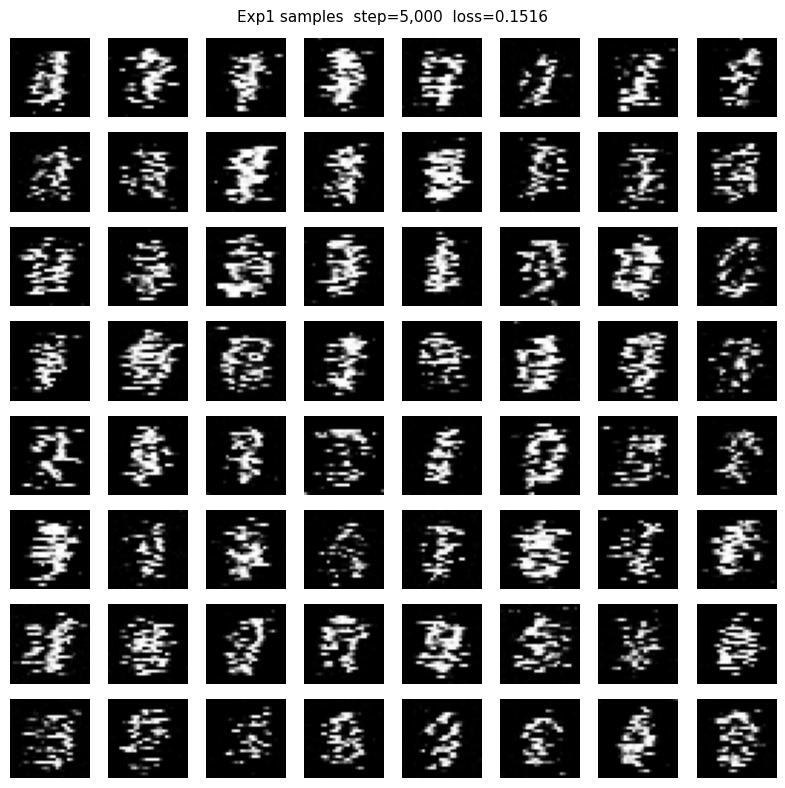


[step 10,000] Checkpoint -> /content/photon-flow-research/outputs/exp1_baseline/checkpoints/step_0010000.pt


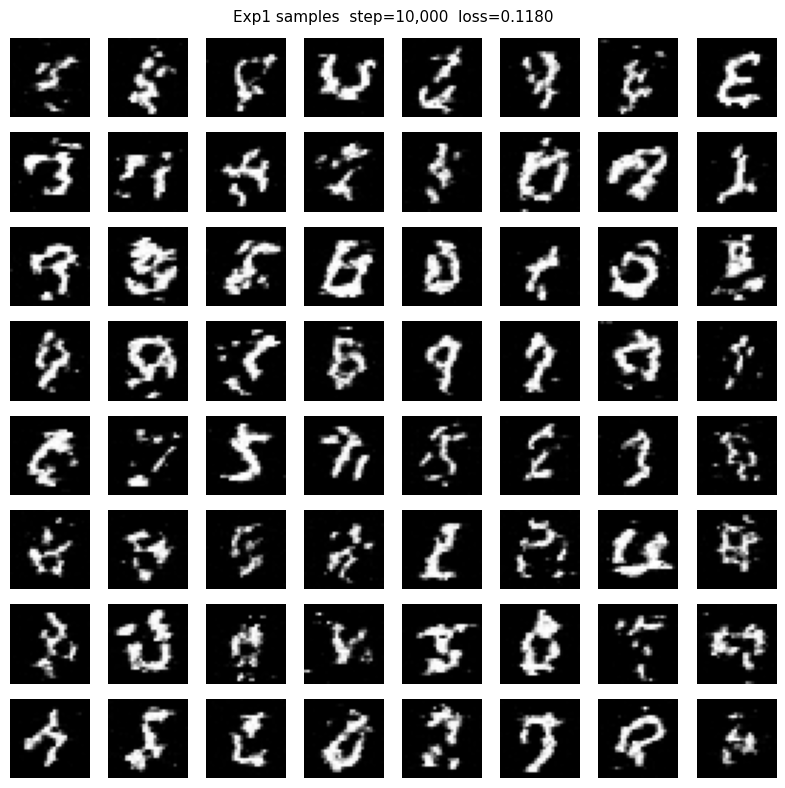

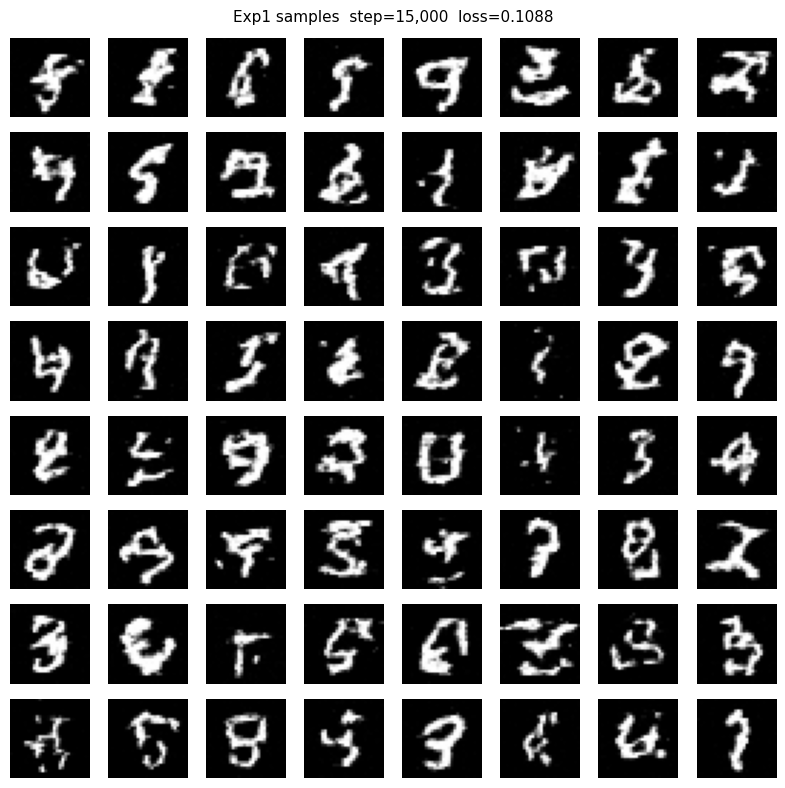


[step 20,000] Checkpoint -> /content/photon-flow-research/outputs/exp1_baseline/checkpoints/step_0020000.pt


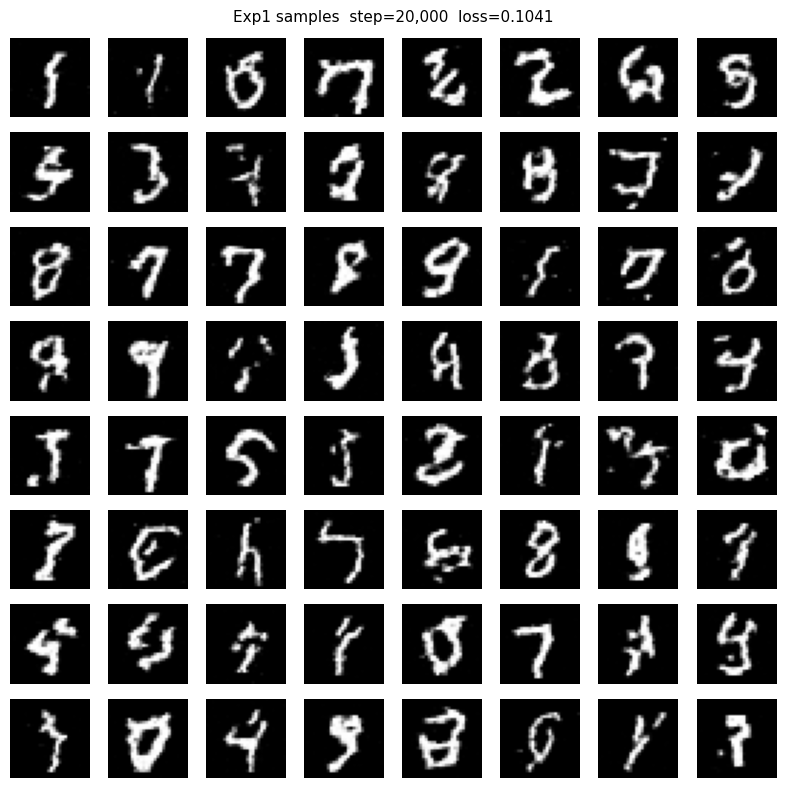

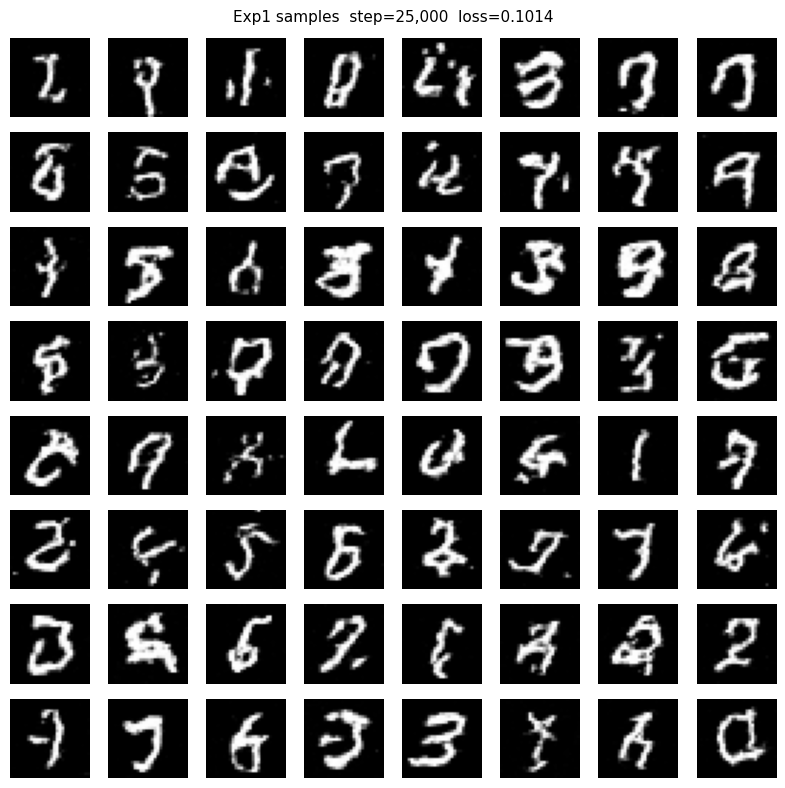


[step 30,000] Checkpoint -> /content/photon-flow-research/outputs/exp1_baseline/checkpoints/step_0030000.pt


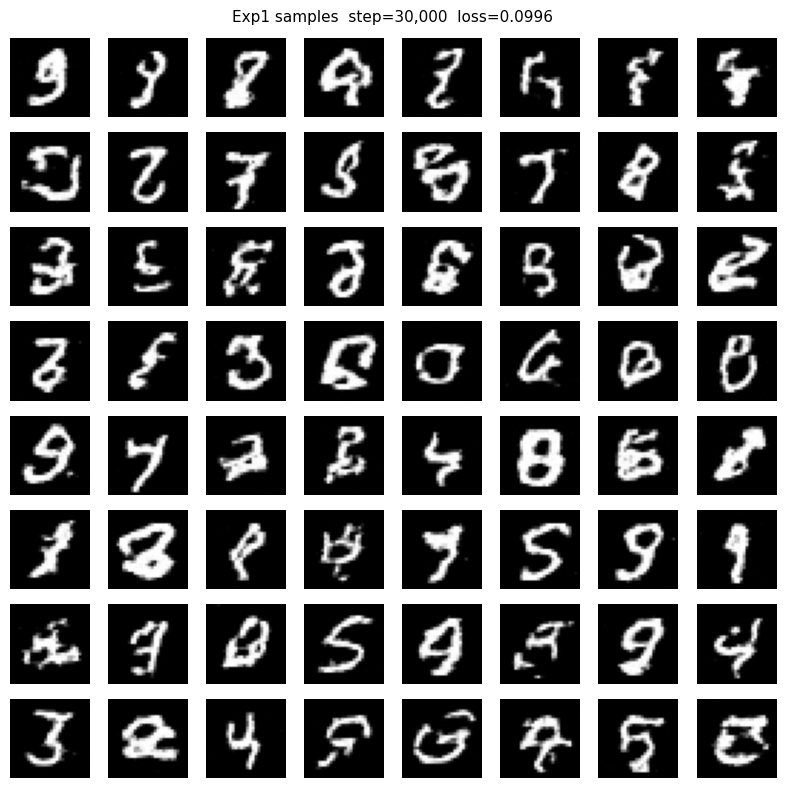

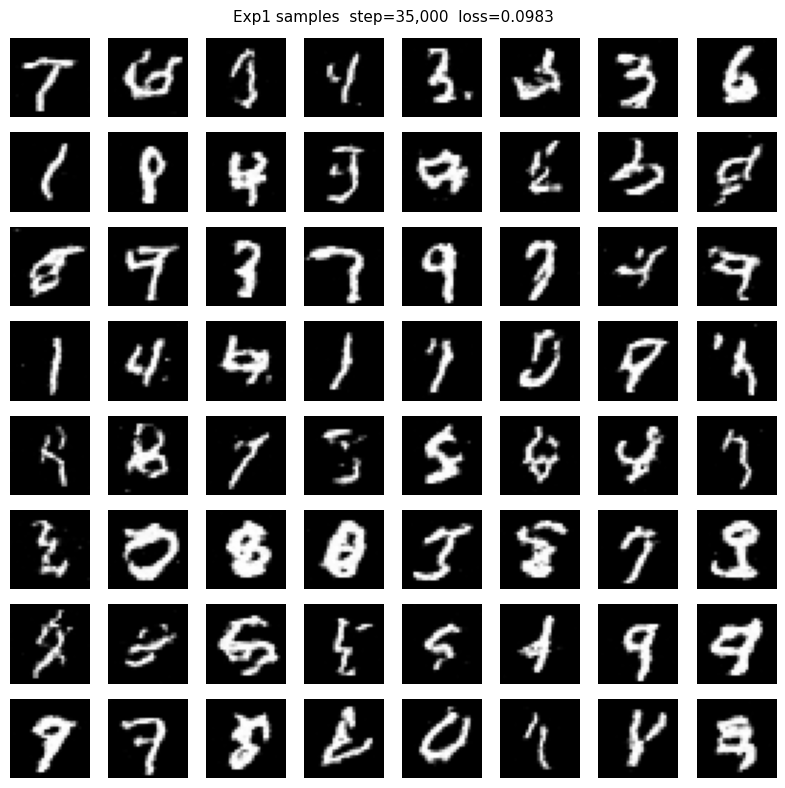


[step 40,000] Checkpoint -> /content/photon-flow-research/outputs/exp1_baseline/checkpoints/step_0040000.pt


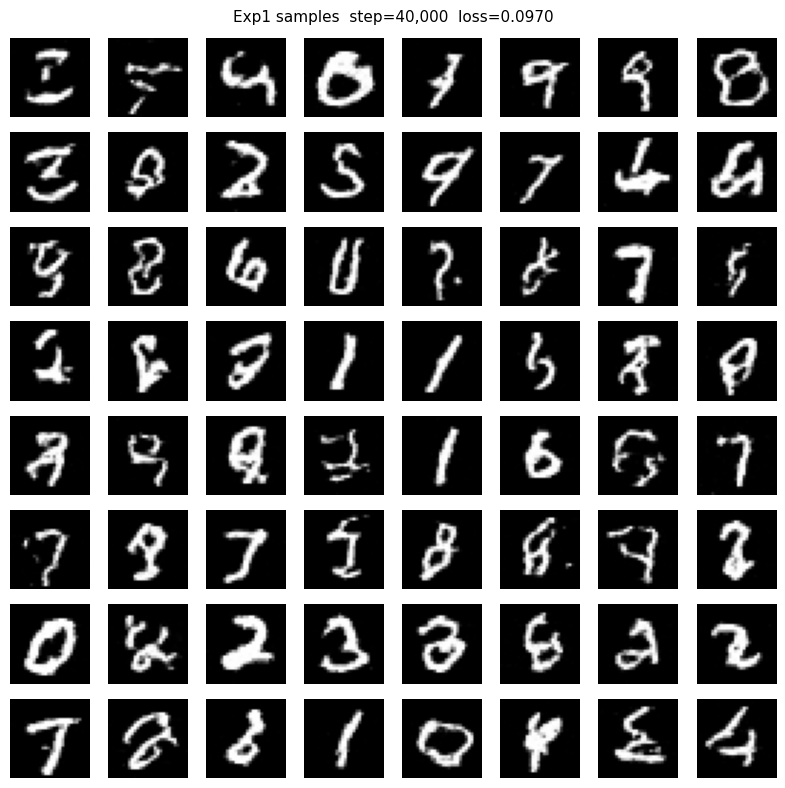

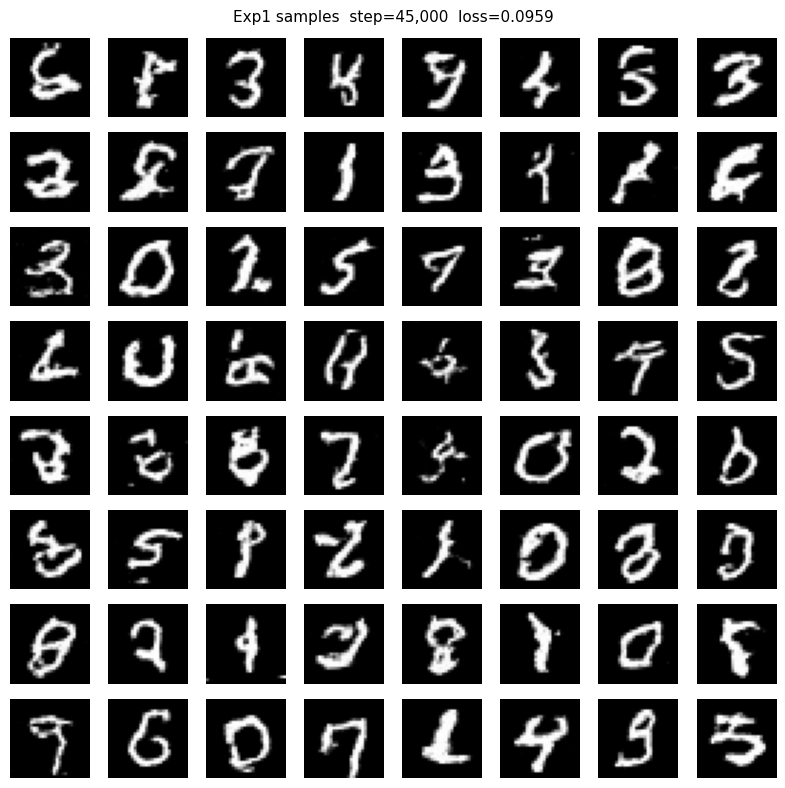


[step 50,000] Checkpoint -> /content/photon-flow-research/outputs/exp1_baseline/checkpoints/step_0050000.pt


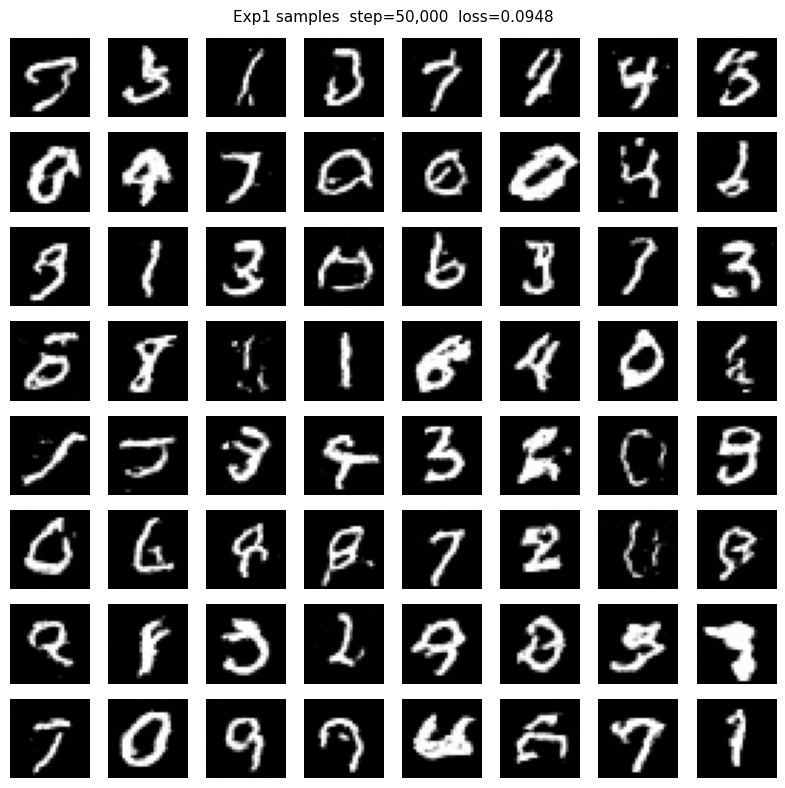

In [ ]:
# ── 10. Training loop (200 000 steps) ─────────────────────────────────────────
# CFM loss (Lipman 2023 Eq. 23) + Adam lr=1e-4
# Checkpoint every 10K steps, sample grid every 5K steps

losses    = []   # per-step losses
step_log  = []   # (step, avg_100) for plotting

data_iter = iter(train_loader)
model.train()

pbar = tqdm(range(CFG["total_steps"]), desc="exp1", dynamic_ncols=True)

for step in pbar:

    # ---- Fetch batch (cycle through dataset across multiple epochs) ----
    try:
        x1, _ = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        x1, _ = next(data_iter)

    x1 = x1.to(device)  # (B, 784)  already flattened by transform

    # ---- CFM loss: L = E||v_theta(x_t,t) - (x1-x0)||^2  (Lipman 2023 Eq.23) ----
    loss = loss_fn(model, x1)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    # ---- Progress logging every 100 steps ----
    if step % 100 == 0:
        avg = float(np.mean(losses[max(0, len(losses)-100):]))
        step_log.append((step, avg))
        pbar.set_postfix(loss=f"{avg:.4f}")

    # ---- Checkpoint every 10K steps ----
    if (step + 1) % CFG["checkpoint_every"] == 0:
        ckpt = {
            "step"                : step + 1,
            "model_state_dict"    : model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "losses"              : losses,
            "config"              : CFG,
        }
        ckpt_path = os.path.join(CKPT_DIR, f"step_{step+1:07d}.pt")
        torch.save(ckpt, ckpt_path)
        print(f"\n[step {step+1:,}] Checkpoint -> {ckpt_path}")

    # ---- Sample grid every 5K steps ----
    if (step + 1) % CFG["sample_every"] == 0:
        model.eval()
        with torch.no_grad():
            # euler_sample: Euler ODE  dx/dt = v_theta(x,t)  t: 0->1
            # Lipman 2023 Section 6.2
            samp = euler_sample(
                model, shape=(64, IN_DIM),
                num_steps=CFG["sample_steps"], device=str(device)
            )
        samp = samp.clamp(0.0, 1.0).cpu().view(64, 1, 28, 28)

        fig, axes = plt.subplots(8, 8, figsize=(8, 8))
        for i, ax in enumerate(axes.flat):
            ax.imshow(samp[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
        avg_now = float(np.mean(losses[max(0, len(losses)-500):]))
        fig.suptitle(f"Exp1 samples  step={step+1:,}  loss={avg_now:.4f}", fontsize=11)
        plt.tight_layout()
        fig_path = os.path.join(FIG_DIR, f"samples_step_{step+1:07d}.png")
        plt.savefig(fig_path, dpi=100, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        model.train()

print(f"\nTraining complete.  Final avg loss (last 1000 steps): "
      f"{np.mean(losses[-1000:]):.4f}")

In [ ]:
# ── 11. Loss curve ────────────────────────────────────────────────────────────

steps_arr  = [s for s, _ in step_log]
losses_arr = [l for _, l in step_log]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(steps_arr, losses_arr, lw=1.5, alpha=0.85, color="steelblue")
ax.set_xlabel("Training step", fontsize=12)
ax.set_ylabel("CFM loss  (MSE)", fontsize=12)
ax.set_title(
    "Exp1 Baseline: Standard CFM + Self-Attention on MNIST (200K steps)",
    fontsize=13
)
ax.grid(True, alpha=0.3)
ax.annotate(
    f"final avg = {np.mean(losses[-1000:]):.4f}",
    xy=(steps_arr[-1], losses_arr[-1]),
    xytext=(-120, 10), textcoords="offset points",
    fontsize=10, color="steelblue"
)
plt.tight_layout()
curve_path = os.path.join(FIG_DIR, "loss_curve.png")
plt.savefig(curve_path, dpi=150)
plt.show()
print(f"Loss curve saved: {curve_path}")
print(f"Loss range: min={min(losses_arr):.4f}  max={max(losses_arr):.4f}")

In [ ]:
# ── 12. Final sample grid (10x10) ─────────────────────────────────────────────
# Reload best (final) checkpoint if desired, then generate 100 samples

# Optionally load best checkpoint:
# final_ckpt = os.path.join(CKPT_DIR, f"step_{CFG['total_steps']:07d}.pt")
# if os.path.exists(final_ckpt):
#     ckpt = torch.load(final_ckpt, map_location=device)
#     model.load_state_dict(ckpt["model_state_dict"])
#     print(f"Loaded checkpoint from step {ckpt['step']}")

model.eval()
with torch.no_grad():
    final_samp = euler_sample(
        model, shape=(100, IN_DIM),
        num_steps=CFG["sample_steps"], device=str(device)
    )
final_samp = final_samp.clamp(0.0, 1.0).cpu().view(100, 1, 28, 28)

fig, axes = plt.subplots(10, 10, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(final_samp[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
fig.suptitle(
    f"Exp1 Final Samples — Baseline CFM + Self-Attention (step {CFG['total_steps']:,})",
    fontsize=13
)
plt.tight_layout()
samp_path = os.path.join(FIG_DIR, "final_samples.png")
plt.savefig(samp_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Final samples saved: {samp_path}")

In [ ]:
# ── 13. FID computation ───────────────────────────────────────────────────────
# FID = Frechet Inception Distance (Heusel et al. 2017)
#   FID = ||mu_r - mu_g||^2 + Tr(Sigma_r + Sigma_g - 2*(Sigma_r Sigma_g)^(1/2))
# Uses InceptionV3 pool3 features (2048-dim)
# Need >= 10K samples for reliable estimate (FIDCalculator warns below this)

N_FID = 10_000   # number of samples for FID
fid_calc = FIDCalculator(device=device)

# ---- Real images: MNIST test set (10K images) ----
# FIDCalculator.extract_features accepts (N, C, H, W) in [0, 1]
real_loader = DataLoader(
    test_ds, batch_size=256, shuffle=False, num_workers=2
)
real_imgs = []
for imgs, _ in real_loader:
    # imgs is (B, 784) from our flatten transform -> reshape to (B,1,28,28)
    real_imgs.append(imgs.view(-1, 1, 28, 28))
real_imgs = torch.cat(real_imgs, dim=0)[:N_FID]  # (N_FID, 1, 28, 28)
print(f"Real images: {real_imgs.shape}  range=[{real_imgs.min():.2f}, {real_imgs.max():.2f}]")

# ---- Generated images: sample N_FID from trained model ----
model.eval()
gen_batches = []
GEN_BATCH = 256
n_generated = 0

with torch.no_grad():
    pbar_fid = tqdm(
        total=N_FID, desc="Generating for FID", unit="img"
    )
    while n_generated < N_FID:
        bs = min(GEN_BATCH, N_FID - n_generated)
        samp = euler_sample(
            model, shape=(bs, IN_DIM),
            num_steps=CFG["sample_steps"], device=str(device)
        )
        gen_batches.append(samp.clamp(0.0, 1.0).cpu().view(bs, 1, 28, 28))
        n_generated += bs
        pbar_fid.update(bs)
    pbar_fid.close()

gen_imgs = torch.cat(gen_batches, dim=0)[:N_FID]  # (N_FID, 1, 28, 28)
print(f"Generated images: {gen_imgs.shape}")

# ---- Extract InceptionV3 features ----
print("Extracting real features  ...")
real_feats = fid_calc.extract_features(real_imgs, batch_size=256)
print(f"  real features: {real_feats.shape}")

print("Extracting generated features  ...")
gen_feats = fid_calc.extract_features(gen_imgs, batch_size=256)
print(f"  gen  features: {gen_feats.shape}")

# ---- Compute FID ----
real_stats = fid_calc.compute_statistics(real_feats)
gen_stats  = fid_calc.compute_statistics(gen_feats)
fid_score  = fid_calc.compute_fid(real_stats, gen_stats)

print(f"\nFID (exp1 baseline, {CFG['total_steps']//1000}K steps): {fid_score:.2f}")
print("(Lower is better. PhotonFlow target: FID <= {:.2f})".format(fid_score * 1.10))

In [ ]:
# ── 14. Results summary ───────────────────────────────────────────────────────

results = {
    "experiment"   : "exp1_baseline",
    "description"  : "Standard CFM + self-attention (4 heads, 4 layers) on MNIST",
    "total_steps"  : CFG["total_steps"],
    "fid"          : round(float(fid_score), 4),
    "fid_target_for_photonflow": round(float(fid_score * 1.10), 4),
    "final_loss_avg1000": round(float(np.mean(losses[-1000:])), 6),
    "model_params" : total_params,
    "architecture" : {
        "type"       : "patch-transformer",
        "patch_size" : CFG["patch_size"],
        "num_patches": NUM_PATCHES,
        "hidden_dim" : CFG["hidden_dim"],
        "num_heads"  : CFG["num_heads"],
        "num_layers" : CFG["num_layers"],
        "time_dim"   : CFG["time_dim"],
        "mlp_ratio"  : CFG["mlp_ratio"],
    },
    "training" : {
        "optimizer"  : "Adam",
        "lr"         : CFG["lr"],
        "batch_size" : CFG["batch_size"],
        "dataset"    : CFG["dataset"],
    },
    "sources" : [
        "Lipman et al. 2023 - Flow Matching for Generative Modeling, ICLR",
        "Peebles & Xie 2023 - Scalable Diffusion Models with Transformers, ICCV",
        "Heusel et al. 2017 - GANs Trained by TTUR, NeurIPS (FID metric)",
    ],
}

results_path = os.path.join(OUTPUT_DIR, "results_exp1.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

SEP = "=" * 58
print(SEP)
print("EXP1 BASELINE RESULTS")
print(SEP)
print(f"  FID (10K samples):        {fid_score:.2f}")
print(f"  PhotonFlow FID target:    <= {fid_score * 1.10:.2f}  (10% budget)")
print(f"  Final CFM loss (avg1K):   {np.mean(losses[-1000:]):.4f}")
print(f"  Model parameters:         {total_params:,}")
print(f"  Training steps:           {CFG['total_steps']:,}")
print(f"  Architecture:             4-layer patch-transformer, 4 heads, hidden=256")
print(SEP)
print(f"  Results saved -> {results_path}")
print(SEP)
print()
print("Next: notebooks/03_exp2_photonflow_mnist.ipynb")
print("      Train PhotonFlow (Monarch layers) and compare FID against this baseline.")